# DATA PREPARATION AND UNDERSTANDING

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go


sns.set(style="whitegrid")

df = pd.read_excel("datos_DANA.xlsx")
df.head()


,ID,nombre_grupo,_id,groupId,missionId,userId,layerId,featureId,status,result,...,urgente_PlantaBaja,urgente_PlantaBaja_dicotomico,danos_Fachada,urgente_Fachada,urgente_Fachada_dicotomico,danos_Perimetro,no_Operativo,danos_Total,urgente_Total,IGD
0,1,MAPEO ALBAL,674044c6e7aca1ff8ab355e3,6730e0a19c42b39965393dac,674044c5e7aca1ff8ab355de,673089939c42b39965383c84,672fac5727d61b4022879129,672fac6027d61b40228797f0,FINISHED,YELLOW,...,0,0,1,0,0,0,0,5,0,6
1,2,MAPEO ALBAL,674044c6e7aca1ff8ab355e5,6730e0a19c42b39965393dac,674044c5e7aca1ff8ab355de,673089939c42b39965383c84,672fac5727d61b4022879129,672fac6027d61b40228797ef,FINISHED,GREEN,...,0,0,0,0,0,0,0,0,0,0
2,3,MAPEO ALBAL,67470faec76254ea5db736b3,6730e0a19c42b39965393dac,67470faec76254ea5db736ac,673089939c42b39965383c84,672fac5727d61b4022879129,672fac6027d61b40228797ec,FINISHED,NONE,...,0,0,0,0,0,0,0,0,0,0
3,4,MAPEO ALBAL,67404374e7aca1ff8ab32943,6730e0a19c42b39965393dac,67404374e7aca1ff8ab3293c,673089939c42b39965383c84,672fac5727d61b4022879129,672fac6027d61b40228797ec,FINISHED,YELLOW,...,0,0,0,0,0,0,0,1,0,1
4,5,MAPEO ALBAL,67470faec76254ea5db736b4,6730e0a19c42b39965393dac,67470faec76254ea5db736ac,673089939c42b39965383c84,672fac5727d61b4022879129,672fac6027d61b40228797eb,FINISHED,YELLOW,...,0,0,1,0,0,0,0,2,0,3


In [28]:
df.info()
df.describe(include='all').T
df.isna().sum().sort_values(ascending=False)
df.columns


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4578 entries, 0 to 4577
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   calle                         4578 non-null   object 
 1   numero                        4578 non-null   int64  
 2   tipologia                     4578 non-null   int64  
 3   usosEdificio.usoPlantaBaja    4578 non-null   object 
 4   usosEdificio.usoPlantasAltas  4578 non-null   object 
 5   result                        4578 non-null   object 
 6   IGD                           4578 non-null   int64  
 7   no_Operativo                  4578 non-null   int64  
 8   danos_Sotano                  4578 non-null   int64  
 9   danos_PlantaBaja              4578 non-null   int64  
 10  danos_Fachada                 4578 non-null   int64  
 11  danos_Perimetro               4578 non-null   int64  
 12  danos_Total                   4578 non-null   int64  
 13  urg

Index(['calle', 'numero', 'tipologia', 'usosEdificio.usoPlantaBaja',
       'usosEdificio.usoPlantasAltas', 'result', 'IGD', 'no_Operativo',
       'danos_Sotano', 'danos_PlantaBaja', 'danos_Fachada', 'danos_Perimetro',
       'danos_Total', 'urgente_Sotano', 'urgente_PlantaBaja',
       'urgente_Fachada', 'urgente_Total', 'datosFachada.cotaAgua',
       'antiguedad_year'],
      dtype='object')

In [5]:
cols_to_drop = [
    'groupId', 'missionId', 'userId', 'layerId', 'featureId', '_id', 
    'status', 'nombre_grupo', 'ID', 'objectId', 'creationDate', 'lastUpdate', 
    'geometry', 'id_municipio', 'municipio', 'addressId', 'taskId'
]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True, errors='ignore')

# Eliminazione colonne completamente vuote o con un'unica categoria
df = df.dropna(axis=1, how='all')
df = df.loc[:, df.nunique() > 1]

df = df.drop_duplicates()
df = df.dropna(how='all')

if 'result' in df.columns:
    df = df[df['result'].notna() & (df['result'] != 'NONE')]

columns_keep = [
    # Identità e posizione
    'calle', 'numero',
    
    # Caratteristiche strutturali e d'uso
    'antiguedad', 'tipologia', 'usosEdificio.usoPlantaBaja', 'usosEdificio.usoPlantasAltas',

    # Ispezione e gravità
    'fechaInspeccion', 'result', 'IGD', 'no_Operativo',
    
    # Indicatori quantitativi di danno e urgenza
    'danos_Sotano', 'danos_PlantaBaja', 'danos_Fachada', 'danos_Perimetro', 'danos_Total',
    'urgente_Sotano', 'urgente_PlantaBaja', 'urgente_Fachada', 'urgente_Perimetro', 'urgente_Total',

    # Livello dell'acqua e contesto ambientale
    'datosFachada.cotaAgua'
]

df = df[[c for c in columns_keep if c in df.columns]]

for col in df.select_dtypes('object'):
    if df[col].dropna().isin(['0','1']).all():
        df[col] = df[col].astype(int)
        
for col in ['danos_Total', 'IGD']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df["antiguedad_year"] = pd.to_datetime(
    df["antiguedad"],
    errors="coerce"
).dt.year

cols_to_drop = ['antiguedad']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True, errors='ignore')

df = df.reset_index(drop=True)

def clean_numeric(col):
    return (
        col.astype(str)
            .str.replace(" ", "", regex=False)
            .str.replace(",", ".", regex=False)
    )

# Lista colonne da convertire
numeric_cols = [
    "datosFachada.cotaAgua",
    "danos_Total", "IGD",
    "danos_Sotano", "danos_PlantaBaja", "danos_Fachada", "danos_Perimetro",
    "urgente_Sotano", "urgente_PlantaBaja", "urgente_Fachada", "urgente_Total"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = clean_numeric(df[col])
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# Pulizia di TUTTE le micro-colonne ".danos" (se presenti)
micro_cols = [c for c in df.columns if c.endswith(".danos")]

for col in micro_cols:
    df[col] = clean_numeric(df[col])
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

print("Pulizia numerica completata.")

if 'antiguedad_year' in df.columns:
    rows_before = df.shape[0]
    df.dropna(subset=['antiguedad_year'], inplace=True)
    print(f"Righe rimosse per 'antiguedad_year' mancante: {rows_before - df.shape[0]}")

# Riempire gli altri valori mancanti con la Moda (valore più frequente)
# Iteriamo su tutte le colonne che hanno ancora valori nulli
for col in df.columns:
    if df[col].isnull().any():
        # Calcoliamo la moda della colonna
        mode_values = df[col].mode()
        
        # Se esiste una moda (il df non è vuoto), usiamo il primo valore trovato
        if not mode_values.empty:
            fill_value = mode_values[0]
            df[col] = df[col].fillna(fill_value)
            # print(f"Colonna '{col}' riempita con la moda: {fill_value}")

# Verifica finale
print(f"Dimensioni finali dataset: {df.shape}")




Pulizia numerica completata.
Righe rimosse per 'antiguedad_year' mancante: 37
Dimensioni finali dataset: (4578, 19)


In [29]:

def normalize_tipologia(val):
    """
    Converte stringhe del tipo:
    'Edificios - Edificios Religioso - Via Crucis'
    in:
    'Edificios Religiosos'
    """
    if pd.isna(val):
        return val

    # spezza in segmenti
    parts = [p.strip() for p in str(val).split("-")]

    if len(parts) < 2:
        return val  # non modificabile

    seconda_parte = parts[1]  # 'Edificios Religioso'

    # rimuove prefisso 'Edificios ' se presente
    if seconda_parte.lower().startswith("edificios "):
        categoria = seconda_parte[len("Edificios "):].strip()
    else:
        categoria = seconda_parte

    # pluralizzazione semplice: aggiunge 's' se non presente
    if not categoria.lower().endswith("s"):
        categoria = categoria + "s"

    # categoria finale standardizzata
    categoria_finale = f"Edificios {categoria}"

    return categoria_finale

# Applica la normalizzazione
if "tipologia" in df.columns:
    df["tipologia"] = df["tipologia"].apply(normalize_tipologia)


In [30]:
# CSV
df.to_csv("dana_valencia_normalizzato.csv", index=False, encoding="utf-8")

# Excel
df.to_excel("dana_valencia_normalizzato.xlsx", index=False)

# Pickle (opzionale, consigliato per ricaricare velocemente)
df.to_pickle("dana_valencia_normalizzato.pkl")

print("File salvati correttamente")


File salvati correttamente


The code loads the original DANA dataset and immediately removes all technical GIS fields, which contain system metadata rather than analytical information. It then eliminates columns that are either empty or constant, followed by the removal of duplicate or entirely blank rows. Only records with a valid damage classification (result) are retained.

A selection of meaningful variables is then extracted, keeping only structural characteristics, usage information, inspection results, damage indicators and the water-level measure. The script corrects data types by converting binary string fields to integers and ensuring that numerical variables such as total damage and IGD are properly interpreted as numeric values.

The construction year is extracted from the antiguedad timestamp and stored in a dedicated variable, after which the original field is discarded. The index is reset, and the final dataset is printed, resulting in a clean and coherent structure ready for visual analysis and modelling.

In [6]:
df.info()
df.describe(include='all').T
df.isna().sum().sort_values(ascending=False)
df.columns

<class 'pandas.core.frame.DataFrame'>
Index: 4578 entries, 0 to 4614
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   calle                         4578 non-null   object 
 1   numero                        4578 non-null   int64  
 2   tipologia                     4578 non-null   object 
 3   usosEdificio.usoPlantaBaja    4578 non-null   object 
 4   usosEdificio.usoPlantasAltas  4578 non-null   object 
 5   result                        4578 non-null   object 
 6   IGD                           4578 non-null   int64  
 7   no_Operativo                  4578 non-null   int64  
 8   danos_Sotano                  4578 non-null   int64  
 9   danos_PlantaBaja              4578 non-null   int64  
 10  danos_Fachada                 4578 non-null   int64  
 11  danos_Perimetro               4578 non-null   int64  
 12  danos_Total                   4578 non-null   int64  
 13  urgente_

Index(['calle', 'numero', 'tipologia', 'usosEdificio.usoPlantaBaja',
       'usosEdificio.usoPlantasAltas', 'result', 'IGD', 'no_Operativo',
       'danos_Sotano', 'danos_PlantaBaja', 'danos_Fachada', 'danos_Perimetro',
       'danos_Total', 'urgente_Sotano', 'urgente_PlantaBaja',
       'urgente_Fachada', 'urgente_Total', 'datosFachada.cotaAgua',
       'antiguedad_year'],
      dtype='object')

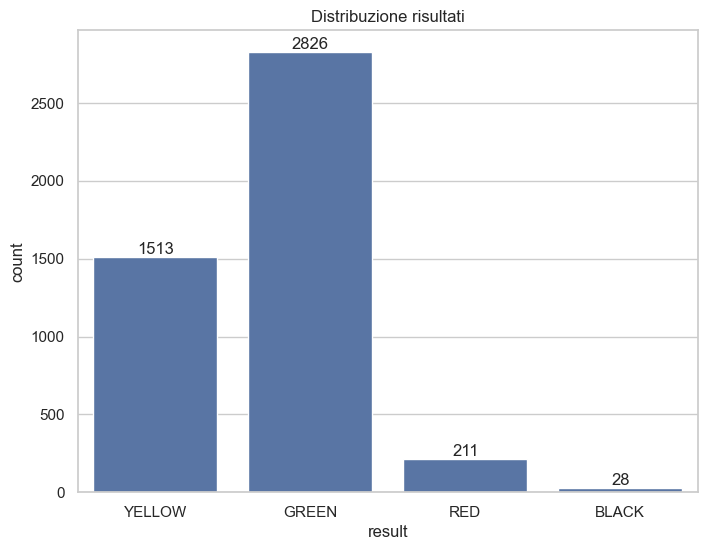

In [32]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x=df["result"])

ax.bar_label(ax.containers[0])

plt.title("Distribuzione risultati")
plt.show()


The chart shows the distribution of damage classes in the dataset. Each bar represents how many buildings were classified as GREEN, YELLOW, RED, or BLACK. The strong predominance of the first two categories indicates that most buildings experienced minor or moderate damage, while the more severe classes are much less frequent, revealing a clear imbalance in the dataset.

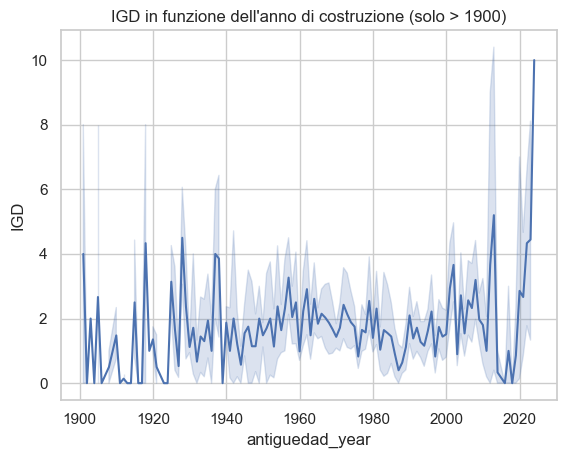

In [39]:
# Filtra solo gli edifici con antiguedad > 1900
df_filtrato = df[df["antiguedad_year"] > 1900]

# Ordina
df_sorted = df_filtrato.sort_values("antiguedad_year")

# Line plot
sns.lineplot(
    x="antiguedad_year",
    y="IGD",
    data=df_sorted
)
plt.title("IGD in funzione dell'anno di costruzione (solo > 1900)")
plt.show()



This plot shows how the IGD (damage severity index) varies with the construction year of the buildings, considering only structures built after 1900. By ordering the data chronologically and visualizing IGD over time, the chart highlights whether newer or older buildings tend to experience higher or more variable damage levels. The resulting trend helps reveal potential structural vulnerabilities related to building age.

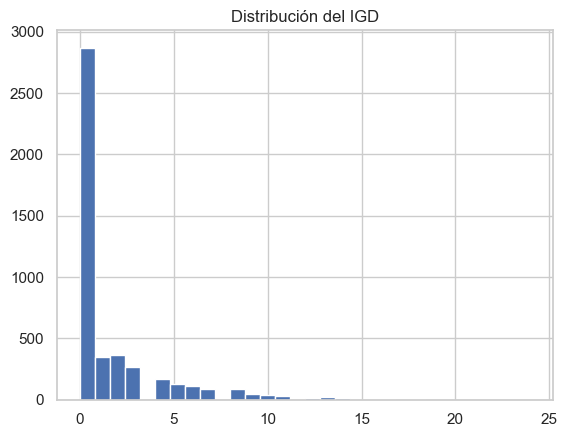

In [41]:
df["IGD"].hist(bins=30)
plt.title("Distribución del IGD")
plt.show()


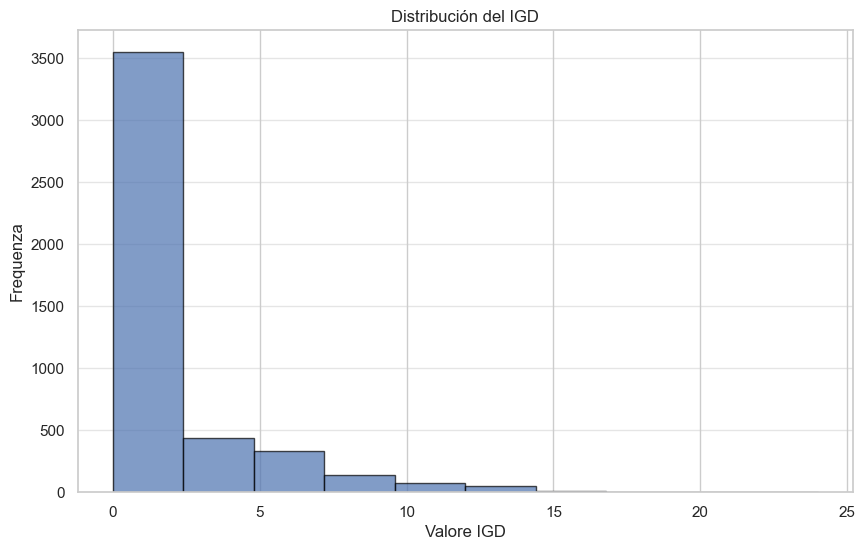


--- Dettaglio Conteggi (Valore: Numero Occorrenze) ---
0: 2844
1: 340
2: 362
3: 264
4: 170
5: 129
6: 112
7: 88
8: 84
9: 51
10: 40
11: 32
12: 15
13: 21
14: 13
15: 2
16: 5
17: 1
18: 3
24: 2


In [34]:
import matplotlib.pyplot as plt

# 1. Generazione del Grafico
plt.figure(figsize=(10, 6))
df["IGD"].hist(edgecolor='black', alpha=0.7)
plt.title("Distribución del IGD")
plt.xlabel("Valore IGD")
plt.ylabel("Frequenza")
plt.grid(axis='y', alpha=0.5)
plt.show()

# 2. Stampa dei conteggi sotto al grafico
print("\n--- Dettaglio Conteggi (Valore: Numero Occorrenze) ---")

# Calcola quante volte appare ogni valore e ordina dal più piccolo al più grande
counts = df["IGD"].value_counts().sort_index()

for valore, numero in counts.items():
    # Se i valori sono interi (es. 0.0), li mostriamo puliti, altrimenti come sono
    val_print = int(valore) if valore == int(valore) else valore
    print(f"{val_print}: {numero}")

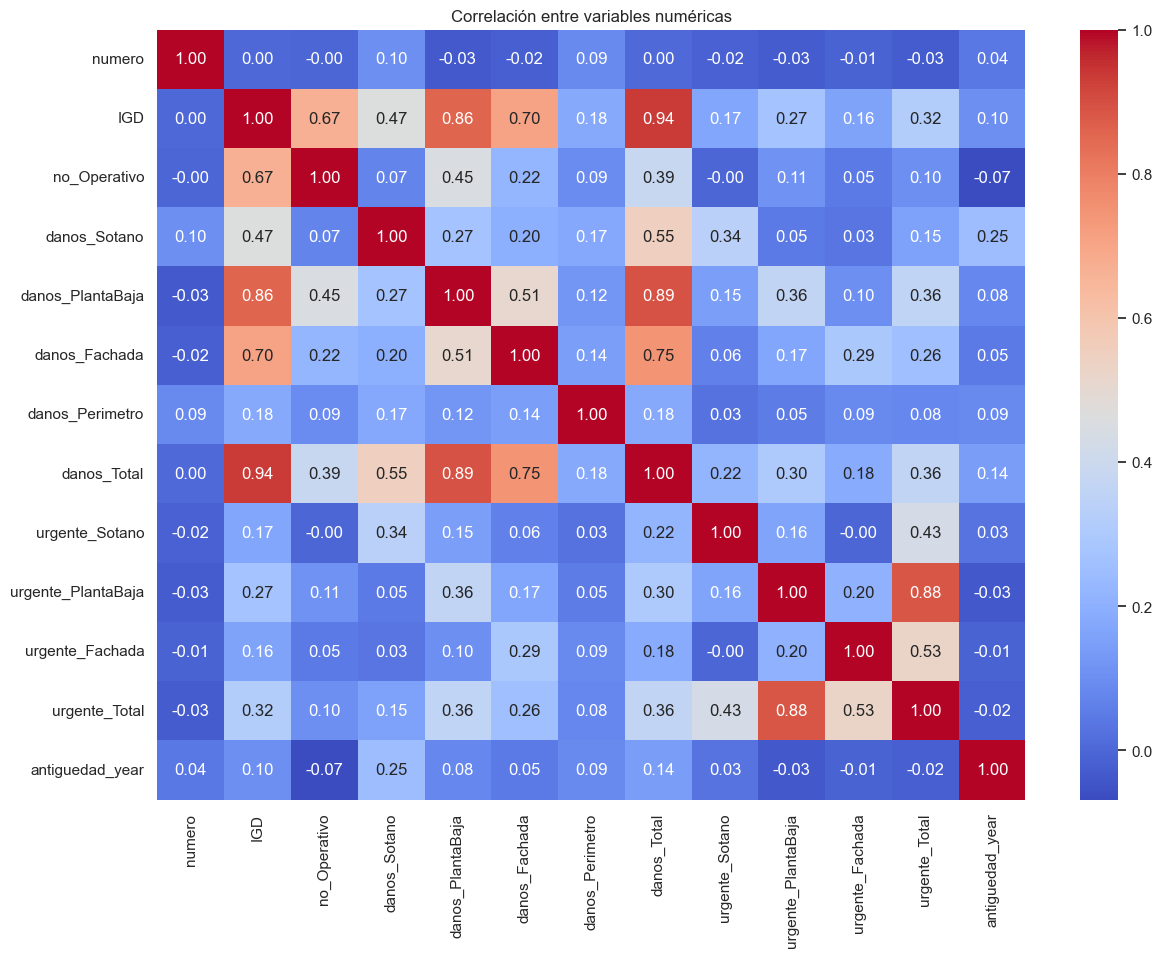

In [76]:
plt.figure(figsize=(14,10))
sns.heatmap(df_num.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre variables numéricas")
plt.show()


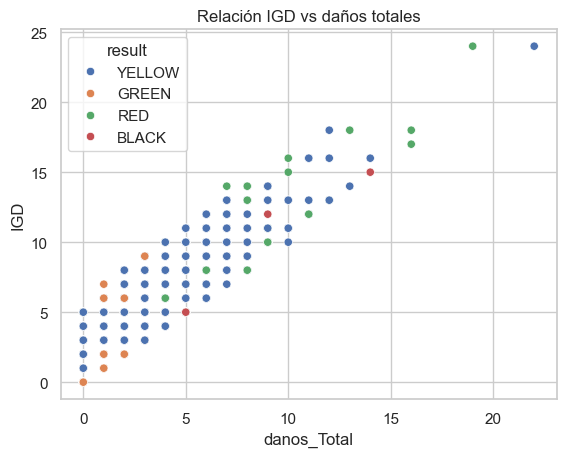

In [45]:
sns.scatterplot(x="danos_Total", y="IGD", hue=df["result"], data=df)
plt.title("Relación IGD vs daños totales")
plt.show()


Although the scatterplot displays only a limited number of points, it still provides a clear visual confirmation of the strong positive relationship between total damage and IGD. The apparent scarcity of points is due to the fact that many buildings share identical values and therefore overlap perfectly in the chart. Despite this limitation, the plot remains useful because it effectively shows the underlying trend between the two variables. However, it is less suitable for representing the true density of the observations, since overlapping points conceal the actual number of buildings in each position.

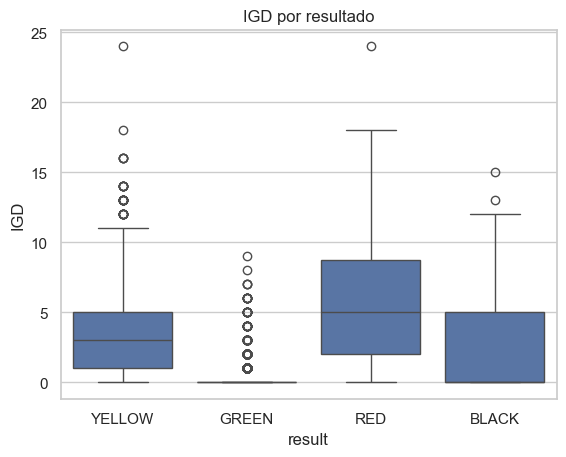

In [47]:
sns.boxplot(x="result", y="IGD", data=df)
plt.title("IGD por resultado")
plt.show()


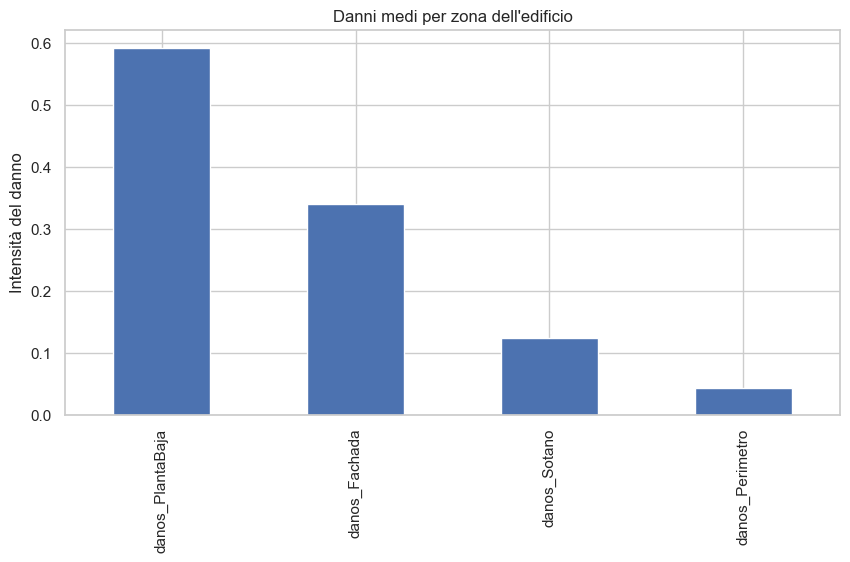

In [49]:
#Individua dove l’evento DANA ha colpito di più.
damage_cols = ["danos_Sotano", "danos_PlantaBaja", "danos_Fachada", "danos_Perimetro"]

df_damage_mean = df[damage_cols].mean().sort_values(ascending=False)

df_damage_mean.plot(kind="bar", figsize=(10,5))
plt.title("Danni medi per zona dell'edificio")
plt.ylabel("Intensità del danno")
plt.show()


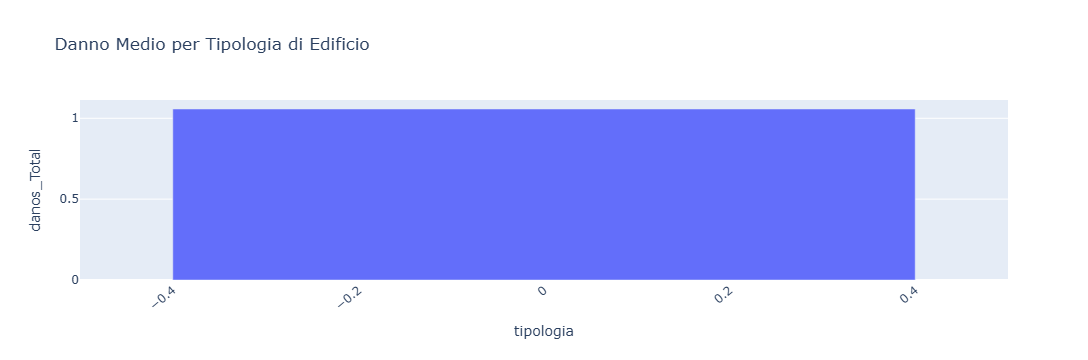

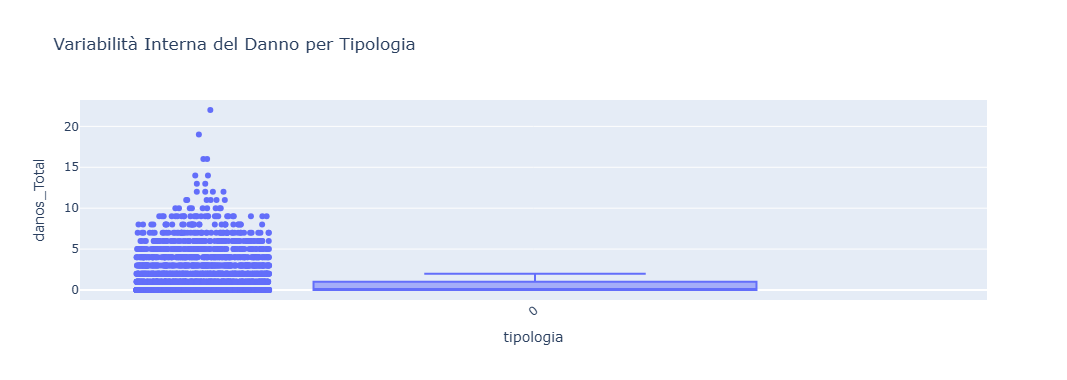

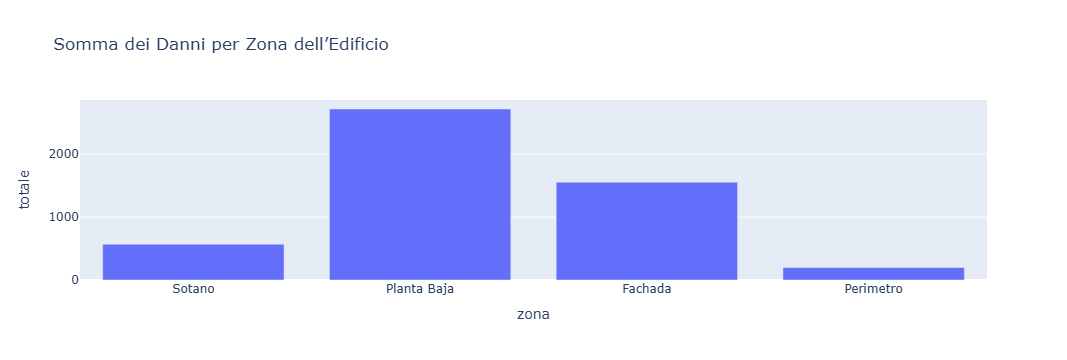

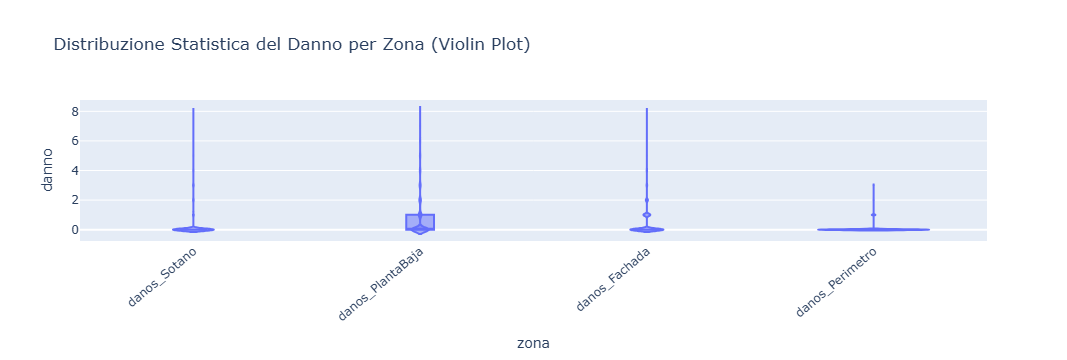

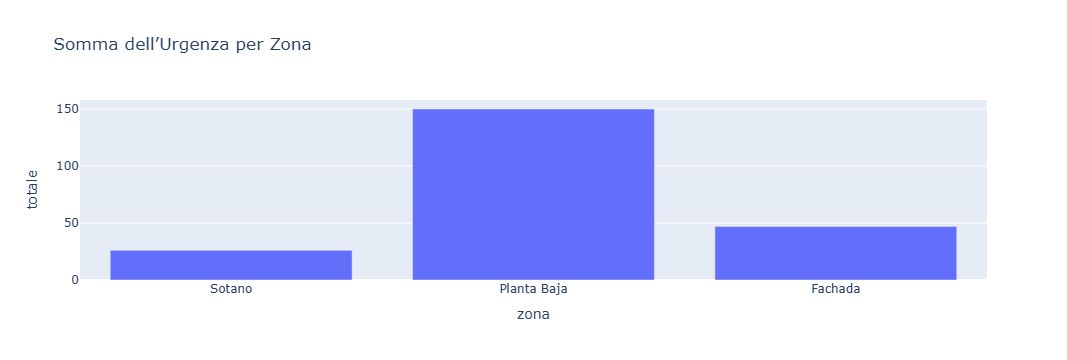

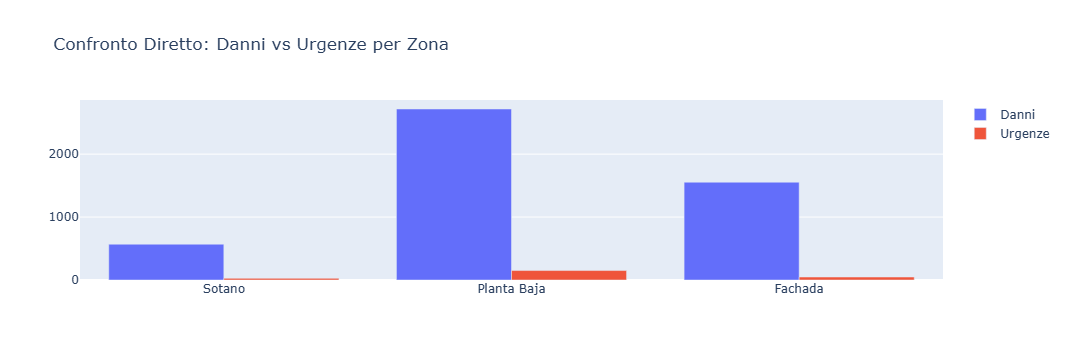

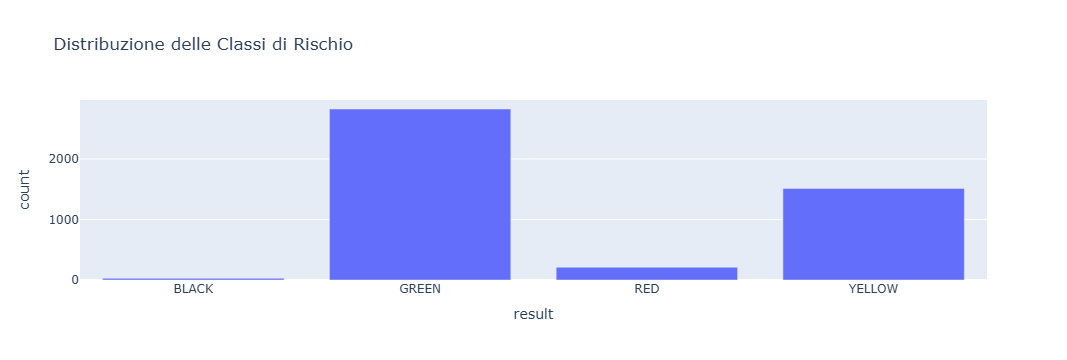

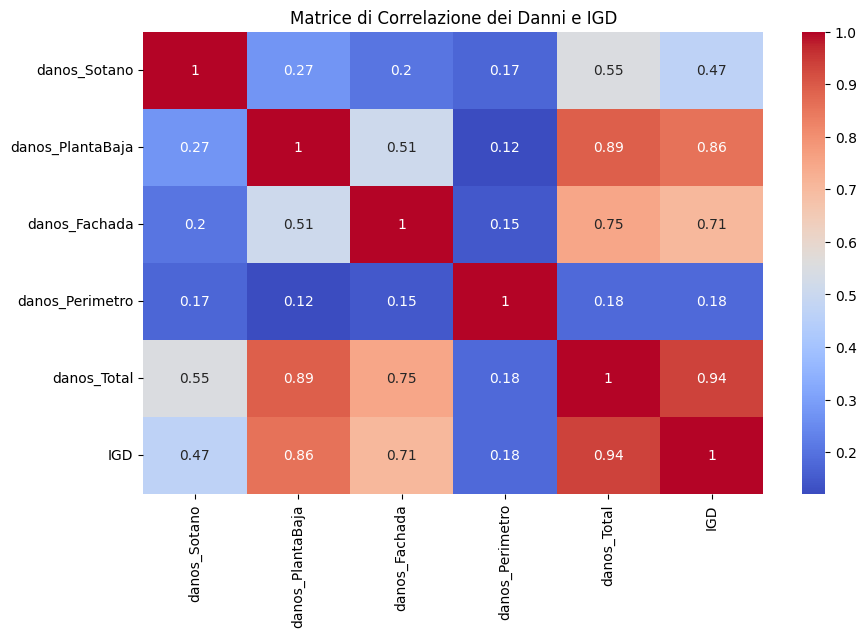

In [7]:
# DANNI PER ZONA (MACRO) — BAR + DENSITÀ

zone_macro = {
    "Sotano": "danos_Sotano",
    "Planta Baja": "danos_PlantaBaja",
    "Fachada": "danos_Fachada",
    "Perimetro": "danos_Perimetro"
}

df_zone = df[list(zone_macro.values())].sum().reset_index()
df_zone.columns = ["col", "totale"]
df_zone["zona"] = df_zone["col"].map({v: k for k, v in zone_macro.items()})

fig_danni_macro = px.bar(
    df_zone,
    x="zona",
    y="totale",
    title="Somma dei Danni per Zona dell’Edificio"
)
fig_danni_macro.show()

# DISTRIBUZIONE STATISTICA DEL DANNO PER ZONA

fig_dist = px.violin(
    df.melt(value_vars=list(zone_macro.values()), var_name="zona", value_name="danno"),
    x="zona",
    y="danno",
    title="Distribuzione Statistica del Danno per Zona (Violin Plot)",
    box=True,
    points=False
)
fig_dist.update_layout(xaxis_tickangle=-40)
fig_dist.show()

#URGENZE PER ZONA + COMPARAZIONE DANNI/URGENZE


urg_cols = {
    "Sotano": "urgente_Sotano",
    "Planta Baja": "urgente_PlantaBaja",
    "Fachada": "urgente_Fachada"
}

df_urg = df[list(urg_cols.values())].sum().reset_index()
df_urg.columns = ["col", "totale"]
df_urg["zona"] = df_urg["col"].map({v: k for k, v in urg_cols.items()})

fig_urg = px.bar(
    df_urg,
    x="zona",
    y="totale",
    title="Somma dell’Urgenza per Zona"
)
fig_urg.show()

# COMPARAZIONE DIRETTA DANNI vs URGENZE (molto utile)

compare = pd.DataFrame({
    "zona": ["Sotano", "Planta Baja", "Fachada"],
    "danni": [
        df["danos_Sotano"].sum(),
        df["danos_PlantaBaja"].sum(),
        df["danos_Fachada"].sum()
    ],
    "urgenze": [
        df["urgente_Sotano"].sum(),
        df["urgente_PlantaBaja"].sum(),
        df["urgente_Fachada"].sum()
    ]
})

fig_compare = go.Figure(data=[
    go.Bar(name="Danni", x=compare["zona"], y=compare["danni"]),
    go.Bar(name="Urgenze", x=compare["zona"], y=compare["urgenze"])
])

fig_compare.update_layout(
    barmode="group",
    title="Confronto Diretto: Danni vs Urgenze per Zona"
)
fig_compare.show()



# CLASSE DI RISCHIO — DISTRIBUZIONE

fig_risk = px.bar(
    df.groupby("result").size().reset_index(name="count"),
    x="result",
    y="count",
    title="Distribuzione delle Classi di Rischio"
)
fig_risk.show()


# MATRICE DI CORRELAZIONE TRA TUTTE LE VARIABILI DI DANNO

corr = df[["danos_Sotano", "danos_PlantaBaja", "danos_Fachada",
           "danos_Perimetro", "danos_Total", "IGD"]].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Matrice di Correlazione dei Danni e IGD")
plt.show()


# Classification

Dimensioni Train Set originale: (3433, 15)
------------------------------------------------------------

>>> 1. MODELLO SENZA SMOTE (Dati Sbilanciati)
Distribuzione classi senza SMOTE:
result
GREEN     2119
YELLOW    1135
RED        158
BLACK       21
Name: count, dtype: int64

CLASSIFICATION REPORT (SENZA SMOTE):
              precision    recall  f1-score   support

       BLACK       0.00      0.00      0.00         7
       GREEN       0.84      0.92      0.88       707
         RED       0.81      0.49      0.61        53
      YELLOW       0.78      0.69      0.73       378

    accuracy                           0.82      1145
   macro avg       0.61      0.53      0.55      1145
weighted avg       0.81      0.82      0.81      1145


>>> 2. MODELLO CON SMOTE (Dati Bilanciati)
Distribuzione classi dopo SMOTE:
result
YELLOW    2119
GREEN     2119
RED       2119
BLACK     2119
Name: count, dtype: int64

CLASSIFICATION REPORT (CON SMOTE):
              precision    recall  f1-score

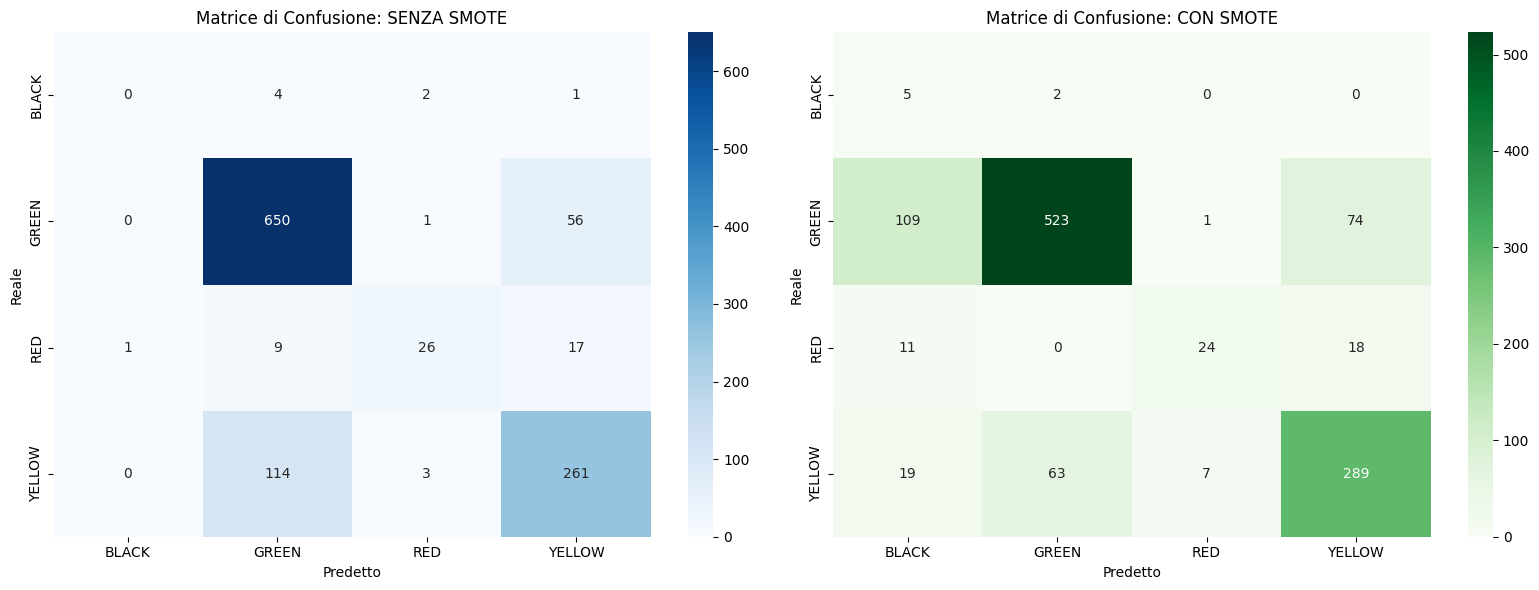

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

df = pd.read_excel("dana_valencia_normalizzato.xlsx")

y = df["result"]
X = df.select_dtypes(include="number")


imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X_imputed, y, test_size=0.25, random_state=42, stratify=y)

print(f"Dimensioni Train Set originale: {X_train.shape}")
print("-" * 60)

print("\n>>> 1. MODELLO SENZA SMOTE (Dati Sbilanciati)")
print(f"Distribuzione classi senza SMOTE:\n{y_train.value_counts()}")

clf_no_smote = DecisionTreeClassifier(max_depth=8, random_state=42)
clf_no_smote.fit(X_train, y_train)

y_pred_no = clf_no_smote.predict(X_test)

print("\nCLASSIFICATION REPORT (SENZA SMOTE):")
print(classification_report(y_test, y_pred_no))

print("\n>>> 2. MODELLO CON SMOTE (Dati Bilanciati)")

sm = SMOTE(random_state=42, k_neighbors=16)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Distribuzione classi dopo SMOTE:\n{y_train_res.value_counts()}")

clf_smote = DecisionTreeClassifier(max_depth=8, random_state=42)
clf_smote.fit(X_train_res, y_train_res)

y_pred_smote = clf_smote.predict(X_test)

print("\nCLASSIFICATION REPORT (CON SMOTE):")
print(classification_report(y_test, y_pred_smote))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm_no = confusion_matrix(y_test, y_pred_no)
sns.heatmap(cm_no, annot=True, fmt='d', cmap="Blues", ax=axes[0], xticklabels=clf_no_smote.classes_, yticklabels=clf_no_smote.classes_)
axes[0].set_title("Matrice di Confusione: SENZA SMOTE")
axes[0].set_xlabel("Predetto")
axes[0].set_ylabel("Reale")

cm_smote = confusion_matrix(y_test, y_pred_smote)
sns.heatmap(cm_smote, annot=True, fmt='d', cmap="Greens", ax=axes[1], xticklabels=clf_smote.classes_, yticklabels=clf_smote.classes_)
axes[1].set_title("Matrice di Confusione: CON SMOTE")
axes[1].set_xlabel("Predetto")
axes[1].set_ylabel("Reale")

plt.tight_layout()
plt.show()

The code builds a complete classification pipeline to predict the damage class (result) using only the numerical features in the dataset. It first separates the target variable from the numerical predictors and applies a median imputation to handle missing values, ensuring that the model receives a clean numeric matrix. The data is then split into training and test sets using stratification to preserve the original class proportions.

Because the dataset is heavily imbalanced, the training portion is processed with SMOTE, an oversampling technique that generates synthetic samples for under-represented classes. This step dramatically increases the number of examples belonging to the rare damage categories, making the classifier more capable of learning their patterns. The code prints the class distribution before and after SMOTE, showing the effect of the balancing procedure.

A Decision Tree classifier with a maximum depth of eight is then trained on the resampled dataset. After training, the model predicts the damage classes for the unseen test set. Finally, a classification report is printed, summarizing precision, recall and F1-score for each class and providing an overall evaluation of the model’s performance on real, non-oversampled data.

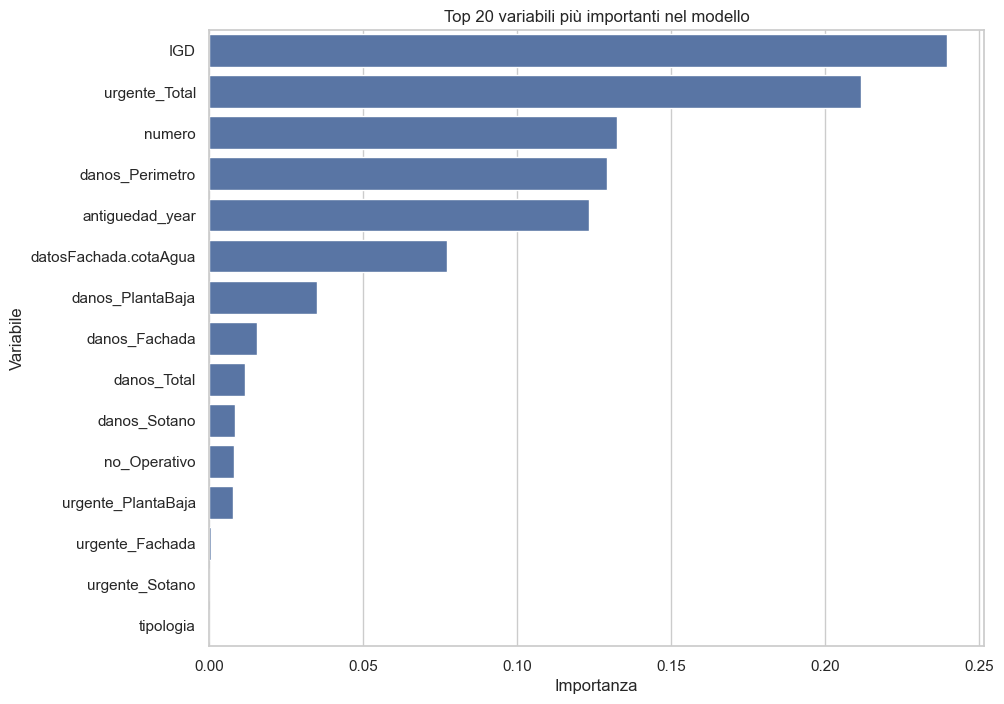

In [27]:
importance = clf_smote.feature_importances_
indices = np.argsort(importance)[::-1]

top_n = 20
top_indices = indices[:top_n]

plt.figure(figsize=(10, 8))
sns.barplot(
    x=importance[top_indices],
    y=X.columns[top_indices]
)
plt.title(f"Top {top_n} variabili più importanti nel modello")
plt.xlabel("Importanza")
plt.ylabel("Variabile")
plt.show()


# Dashbboard and LLM

In [5]:

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from dash import Dash, dcc, html, Input, Output, State
from dash import dash_table
from geopy.geocoders import Nominatim
import time, os, re
import requests
import json


# FUNZIONI ASSISTENTE AI (LM STUDIO)


def ask_for_plot_code(query):
    """
    Interroga LLaMA 3.1 via LM Studio e ottiene SOLO codice Python Plotly.
    """
    url = "http://localhost:1234/v1/chat/completions"

    prompt = f"""
Sei un assistente di data science.
Rispondi SOLO con codice Python valido che crea un grafico Plotly.

Regole IMPORTANTI:
- Nessun testo fuori dal codice.
- Nessun commento.
- Importa solo: import plotly.express as px
- Il DataFrame esiste già come df.
- Crea la figura e assegnala a: fig = ...

Domanda dell’utente:
{query}
"""

    payload = {
        "model": "meta-llama-3.1-8b-instruct",
        "messages": [{"role": "user", "content": prompt}],
        "temperature": 0
    }

    r = requests.post(url, json=payload)
    r.raise_for_status()
    data = r.json()
    result = data["choices"][0]["message"]["content"]

    # Rimuove eventuali blocchi ```python ... ```
    clean = re.sub(r"```python", "", result)
    clean = re.sub(r"```", "", clean).strip()

    return clean


def run_plot_code(code, df):
    try:
        # ambiente locale isolato: nessuna contaminazione globale
        local_env = {"df": df, "px": px, "go": go}
        exec(code, {}, local_env)
        fig = local_env.get("fig", go.Figure())
        return fig, ""
    except Exception as e:
        return go.Figure(), f"Errore esecuzione codice AI: {str(e)}"



# CARICAMENTO DATI


df = pd.read_excel("dana_valencia_normalizzato.xlsx")

# Fix variabili
df["usosEdificio.usoPlantaBaja"] = df["usosEdificio.usoPlantaBaja"].fillna("Sconosciuto")
df["tipologia"] = df["tipologia"].fillna("Sconosciuto")
df["datosFachada.cotaAgua"] = pd.to_numeric(df["datosFachada.cotaAgua"], errors="coerce")
df["urgente_Total"] = pd.to_numeric(df.get("urgente_Total", 0), errors="coerce").fillna(0)
df["danos_Total"] = pd.to_numeric(df["danos_Total"], errors="coerce")
df["IGD"] = pd.to_numeric(df["IGD"], errors="coerce")
df["antiguedad_year"] = pd.to_numeric(df["antiguedad_year"], errors="coerce")

# Danni/urgenza per zona → numeric
for col in [
    "danos_Sotano", "danos_PlantaBaja", "danos_Fachada", "danos_Perimetro",
    "urgente_Sotano", "urgente_PlantaBaja", "urgente_Fachada", "urgente_Perimetro"
]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)


# NORMALIZZAZIONE VIE


def normalize_street(s):
    try:
        s = str(s).lower().strip()
        s = re.sub(r'^(cl|av|avda|calle|c/|c |pza|plz|plaza)\s+', '', s)
        s = re.sub(r'\s+', ' ', s)
        return s
    except:
        return None

df["calle_norm"] = df["calle"].apply(normalize_street)

# GEOCODIFICA (cache)


GEOCODE_FILE = "street_coords_norm.csv"

if not os.path.exists(GEOCODE_FILE):

    geolocator = Nominatim(user_agent="dana-valencia")

    unique_streets = df["calle_norm"].dropna().unique()
    street_coords = []

    for street in unique_streets:
        query = f"{street}, Valencia, España"
        try:
            loc = geolocator.geocode(query, timeout=10)
            if loc:
                lat, lon = loc.latitude, loc.longitude
            else:
                lat, lon = None, None
        except:
            lat, lon = None, None

        street_coords.append([street, lat, lon])
        time.sleep(1)

    df_coords = pd.DataFrame(street_coords, columns=["calle_norm", "lat", "lon"])
    df_coords.to_csv(GEOCODE_FILE, index=False)

else:
    df_coords = pd.read_csv(GEOCODE_FILE)


#  MERGE COORDINATE


df = df.merge(df_coords, on="calle_norm", how="left")
df_geo = df[(~df["lat"].isna()) & (~df["lon"].isna())]



# CLASSIFICAZIONE EDIFICI VECCHI/NUOVI


def classify_age(year, cutoff=1970):
    try:
        y = int(year)
        return "Vecchio" if y < cutoff else "Nuovo"
    except:
        return "Sconosciuto"

df["categoria_eta"] = df["antiguedad_year"].apply(classify_age)



# DASH APP


app = Dash(__name__)
app.title = "DANA Valencia Dashboard PRO"


#  COLONNE TABELLA DETTAGLIO


table_base = ["calle", "numero", "result", "IGD", "danos_Total",
              "antiguedad_year", "urgente_Total"]

extra = [
    "danos_Sotano", "danos_PlantaBaja", "danos_Fachada", "danos_Perimetro",
    "urgente_Sotano", "urgente_PlantaBaja", "urgente_Fachada", "urgente_Perimetro",
    "datosFachada.cotaAgua"
]

cols_table = [c for c in table_base + extra if c in df.columns]


# LAYOUT — TABS 

app.layout = html.Div([

    html.H1("Dashboard DANA Valencia – Versione Professionale", style={"textAlign": "center"}),

    dcc.Tabs([

        
        # TAB 1 — HEATMAP DANNI
        
        dcc.Tab(label="Heatmap Danni", children=[
            dcc.Dropdown(
                id="filtro_result",
                options=[{"label": x, "value": x} for x in df["result"].unique()],
                value="GREEN"
            ),
            dcc.Graph(id="heatmap")
        ]),

        
        # TAB 2 — DETTAGLIO EDIFICIO
        
        dcc.Tab(label="Dettaglio Edificio", children=[

            html.H3("Seleziona un edificio dalla tabella per vedere i dettagli"),

            dash_table.DataTable(
                id="tabella_edifici",
                columns=[{"name": c.replace("_", " ").capitalize(), "id": c} for c in table_base],
                data=df[cols_table].to_dict("records"),
                filter_action="native",
                sort_action="native",
                page_size=12,
                row_selectable="single",
                selected_rows=[0],
                style_table={"height": "350px", "overflowY": "auto"},
                style_cell={"textAlign": "left", "padding": "6px"},
                style_header={"backgroundColor": "#f0f0f0", "fontWeight": "bold"},
            ),

            html.Br(),

            html.Div([
                dcc.Graph(id="grafico_danni_edificio", style={"flex": "1", "minWidth": "300px"}),
                dcc.Graph(id="grafico_urgenze_edificio", style={"flex": "1", "minWidth": "300px"}),
            ], style={"display": "flex", "flexWrap": "wrap", "gap": "20px"}),

            dcc.Graph(id="grafico_posizione_edificio"),

            html.Div(id="dettagli_edificio",
                     style={"background": "#fafafa", "padding": "20px",
                            "borderRadius": "10px", "marginTop": "10px"})
        ]),

        
        # TAB 3 — KPI GLOBALI
        
        dcc.Tab(label="KPI", children=[

            html.Div(id="kpi_rischio",
                     style={"display": "flex", "gap": "40px", "flexWrap": "wrap",
                            "marginBottom": "20px"}),

            dcc.Graph(id="grafico_distribuzione_result"),
            dcc.Graph(id="grafico_tipologia_danni")
        ]),

        
        # TAB 4 — SEVERITÀ RISCHIO
        
        dcc.Tab(label="Severità Rischio", children=[

            html.Div([
                html.Div([
                    html.Label("Soglia IGD:"),
                    dcc.Slider(
                        id="soglia_igd",
                        min=float(df["IGD"].min()),
                        max=float(df["IGD"].max()),
                        step=0.5,
                        value=float(df["IGD"].quantile(0.75)),
                        tooltip={"placement": "bottom", "always_visible": True}
                    )
                ], style={"flex": "1", "minWidth": "250px"}),

                html.Div([
                    html.Label("Soglia Danni Totali:"),
                    dcc.Slider(
                        id="soglia_danno",
                        min=float(df["danos_Total"].min()),
                        max=float(df["danos_Total"].max()),
                        step=5,
                        value=float(df["danos_Total"].quantile(0.75)),
                        tooltip={"placement": "bottom", "always_visible": True}
                    )
                ], style={"flex": "1", "minWidth": "250px", "marginLeft": "20px"}),

            ], style={"display": "flex", "flexWrap": "wrap", "marginBottom": "30px"}),

            html.Div(id="kpi_severita",
                     style={"display": "flex", "gap": "40px",
                            "flexWrap": "wrap", "marginBottom": "20px"}),

            dcc.Graph(id="grafico_ist_igd"),
            dcc.Graph(id="grafico_scatter_severita"),
            dcc.Graph(id="grafico_severita_tipologia")
        ]),

        
        # TAB 5 — EDIFICI URGENTI
        
        dcc.Tab(label="Edifici Urgenti", children=[
            dcc.Graph(id="mappa_urgenti")
        ]),

        
        # TAB 6 — EDIFICI VECCHI vs NUOVI (NUOVA)
        
        dcc.Tab(label="Edifici Vecchi vs Nuovi", children=[

            html.H3("Confronto tra edifici vecchi e nuovi"),

            html.Label("Scegli l’anno soglia per definire 'vecchio' vs 'nuovo':"),
            dcc.Slider(
                id="anno_soglia",
                min=1900,
                max=int(df["antiguedad_year"].max()),
                value=1970,
                step=1,
                tooltip={"placement": "bottom", "always_visible": True}
            ),

            html.Br(),

            dcc.Graph(id="grafico_danni_eta"),
            dcc.Graph(id="grafico_igd_eta"),
            dcc.Graph(id="grafico_acqua_danni_eta"),
            dcc.Graph(id="grafico_urgenze_eta")
        ]),

        
        # TAB 7 — ASSISTENTE AI
        
        dcc.Tab(label="Assistente AI", children=[

            html.H3("Assistente AI – Generazione Automatica di Grafici"),

            dcc.Textarea(
                id="ai_query",
                placeholder="Es: Mostrami uno scatter tra IGD e danos_Total",
                value="",
                style={"width": "100%", "height": "140px"}
            ),

            html.Br(),
            html.Button("Genera Grafico", id="ai_button", n_clicks=0),

            html.Div(id="ai_error", style={"color": "red", "marginTop": "10px"}),

            dcc.Graph(id="ai_plot")
        ]),

    ])
])


# CALLBACKS


#  CALLBACK ASSISTENTE AI 
@app.callback(
    Output("ai_plot", "figure"),
    Output("ai_error", "children"),
    Input("ai_button", "n_clicks"),
    State("ai_query", "value"),
    prevent_initial_call=True
)
def ai_generate_plot(n_clicks, query):
    if not query or not query.strip():
        return go.Figure(), "Inserisci una domanda valida."

    code = ask_for_plot_code(query)
    fig, error = run_plot_code(code, df)

    return fig, error


#  HEATMAP 
@app.callback(
    Output("heatmap", "figure"),
    Input("filtro_result", "value")
)
def update_heatmap(selected):

    df_f = df_geo[df_geo["result"] == selected]

    return px.density_mapbox(
        df_f, lat="lat", lon="lon", z="danos_Total",
        radius=55, zoom=12,
        center={"lat": 39.47, "lon": -0.38},
        mapbox_style="carto-positron",
        title=f"Heatmap Danni — {selected}"
    )


#  DETTAGLIO EDIFICIO 
@app.callback(
    Output("dettagli_edificio", "children"),
    Output("grafico_danni_edificio", "figure"),
    Output("grafico_urgenze_edificio", "figure"),
    Output("grafico_posizione_edificio", "figure"),
    Input("tabella_edifici", "selected_rows"),
    Input("tabella_edifici", "data")
)
def dettaglio_edificio(selected_rows, data):

    if not data:
        return "Nessun dato.", go.Figure(), go.Figure(), go.Figure()

    idx = selected_rows[0] if selected_rows else 0
    r = data[idx]

    # TESTO
    dettagli = html.Div([
        html.H3("Dettaglio edificio"),
        html.P(f"{r.get('calle','')} {r.get('numero','')}"),
        html.P(f"Classe rischio: {r.get('result','')}"),
        html.P(f"IGD: {r.get('IGD','')}"),
        html.P(f"Danni Totali: {r.get('danos_Total','')}"),
        html.P(f"Anno costruzione: {r.get('antiguedad_year','')}"),
        html.P(f"Urgenza Totale: {r.get('urgente_Total','')}"),
        html.P(f"Cota acqua: {r.get('datosFachada.cotaAgua','N/A')}")
    ])

    # DANNO PER ZONA
    mapping_danni = {
        "Sotano": r.get("danos_Sotano", 0),
        "Planta Baja": r.get("danos_PlantaBaja", 0),
        "Fachada": r.get("danos_Fachada", 0),
        "Perimetro": r.get("danos_Perimetro", 0)
    }
    fig_danni = px.bar(
        x=list(mapping_danni.keys()),
        y=list(mapping_danni.values()),
        title="Danni per Zona",
        labels={"x": "Zona", "y": "Danni"}
    )

    # URGENZA PER ZONA
    mapping_urg = {
        "Sotano": r.get("urgente_Sotano", 0),
        "Planta Baja": r.get("urgente_PlantaBaja", 0),
        "Fachada": r.get("urgente_Fachada", 0),
        "Perimetro": r.get("urgente_Perimetro", 0)
    }
    fig_urg = px.bar(
        x=list(mapping_urg.keys()),
        y=list(mapping_urg.values()),
        title="Urgenza per Zona",
        labels={"x": "Zona", "y": "Urgenza"}
    )

    # POSIZIONE NELLO SPAZIO IGD–DANNI
    fig_pos = px.scatter(
        df,
        x="danos_Total", y="IGD",
        color="result", opacity=0.25,
        title="Posizione nel Piano IGD–Danni"
    )
    fig_pos.add_scatter(
        x=[r.get("danos_Total", 0)],
        y=[r.get("IGD", 0)],
        mode="markers",
        marker=dict(size=14, symbol="star"),
        name="Edificio selezionato"
    )

    return dettagli, fig_danni, fig_urg, fig_pos


#  KPI GLOBALI 
@app.callback(
    Output("kpi_rischio", "children"),
    Input("heatmap", "figure")
)
def kpi(_):

    tot = len(df)
    red = (df["result"] == "RED").sum()
    urg = (df["urgente_Total"] > 0).sum()

    igd = df["IGD"].mean()
    dan = df["danos_Total"].mean()

    def box(title, value):
        return html.Div([
            html.Div(title, style={"fontWeight": "bold"}),
            html.Div(value, style={"fontSize": "22px"})
        ], style={"background": "#f5f5f5", "padding": "15px",
                  "borderRadius": "10px", "minWidth": "200px"})

    return [
        box("Totale Edifici", f"{tot}"),
        box("Edifici RED", f"{red} ({red/tot*100:.1f}%)"),
        box("Edifici Urgenti", f"{urg} ({urg/tot*100:.1f}%)"),
        box("IGD Medio", f"{igd:.2f}"),
        box("Danno Medio", f"{dan:.2f}")
    ]


@app.callback(
    Output("grafico_distribuzione_result", "figure"),
    Input("heatmap", "figure")
)
def dist_result(_):
    t = df.groupby("result").size().reset_index(name="count")
    return px.bar(t, x="result", y="count",
                  title="Distribuzione Classi di Rischio")


@app.callback(
    Output("grafico_tipologia_danni", "figure"),
    Input("heatmap", "figure")
)
def dan_per_tipologia(_):
    t = (
        df.groupby("tipologia")["danos_Total"]
        .mean().reset_index()
        .sort_values("danos_Total", ascending=False)
        .head(10)
    )
    fig = px.bar(t, x="tipologia", y="danos_Total",
                 title="Danno Medio per Tipologia (Top 10)")
    fig.update_layout(xaxis_tickangle=-45)
    return fig


#  SEVERITÀ RISCHIO 
@app.callback(
    Output("kpi_severita", "children"),
    Output("grafico_ist_igd", "figure"),
    Output("grafico_scatter_severita", "figure"),
    Output("grafico_severita_tipologia", "figure"),
    Input("soglia_igd", "value"),
    Input("soglia_danno", "value")
)
def severita(soglia_igd, soglia_danno):

    mask = (df["IGD"] >= soglia_igd) & (df["danos_Total"] >= soglia_danno)
    df2 = df.copy()
    df2["severita"] = np.where(mask, "Alta Severità", "Altro")

    high = mask.sum()
    tot = len(df)

    def box(title, value):
        return html.Div([
            html.Div(title, style={"fontWeight": "bold"}),
            html.Div(value, style={"fontSize": "22px"})
        ], style={"background": "#f5f5f5", "padding": "15px",
                  "borderRadius": "10px", "minWidth": "230px"})

    kpi = [
        box("Edifici Alta Severità", f"{high} ({high/tot*100:.1f}%)"),
        box("Soglia IGD", f"{soglia_igd}"),
        box("Soglia Danni", f"{soglia_danno}")
    ]

    # Istogramma IGD
    fig_hist = px.histogram(df2, x="IGD", color="severita",
                            nbins=30, title="Distribuzione IGD")
    fig_hist.update_traces(opacity=0.6)

    # Scatter IGD vs Danni
    fig_scat = px.scatter(
        df2, x="danos_Total", y="IGD",
        color="severita",
        title="Piano IGD vs Danni — Evidenza Alta Severità"
    )

    # Tipologie più comuni in alta severità
    df_high = df2[df2["severita"] == "Alta Severità"]
    if len(df_high) > 0:
        t = (
            df_high.groupby("tipologia").size()
            .reset_index(name="count")
            .sort_values("count", ascending=False)
            .head(10)
        )
        fig_tip = px.bar(t, x="tipologia", y="count",
                         title="Tipologie Edifici Alta Severità")
        fig_tip.update_layout(xaxis_tickangle=-45)
    else:
        fig_tip = go.Figure()

    return kpi, fig_hist, fig_scat, fig_tip


#  EDIFICI URGENTI 
@app.callback(
    Output("mappa_urgenti", "figure"),
    Input("heatmap", "figure")
)
def urgenti(_):

    df_u = df_geo[df_geo["urgente_Total"] > 0]

    return px.scatter_mapbox(
        df_u, lat="lat", lon="lon",
        size="urgente_Total", color="urgente_Total",
        zoom=12, center={"lat": 39.47, "lon": -0.38},
        mapbox_style="carto-positron",
        title="Edifici Urgenti"
    )



# CALLBACK — EDIFICI VECCHI vs NUOVI


@app.callback(
    Output("grafico_danni_eta", "figure"),
    Output("grafico_igd_eta", "figure"),
    Output("grafico_acqua_danni_eta", "figure"),
    Output("grafico_urgenze_eta", "figure"),
    Input("anno_soglia", "value")
)
def eta_dashboard(soglia):

    df_eta = df.copy()
    df_eta["categoria_eta"] = df_eta["antiguedad_year"].apply(
        lambda y: "Vecchio" if y < soglia else "Nuovo"
    )

    # Danni medi
    danni_mean = df_eta.groupby("categoria_eta")["danos_Total"].mean().reset_index()
    fig_danni = px.bar(
        danni_mean, x="categoria_eta", y="danos_Total",
        title="Danno Medio — Edifici Vecchi vs Nuovi",
        labels={"categoria_eta": "Categoria", "danos_Total": "Danno Medio"}
    )

    # IGD medio
    igd_mean = df_eta.groupby("categoria_eta")["IGD"].mean().reset_index()
    fig_igd = px.bar(
        igd_mean, x="categoria_eta", y="IGD",
        title="IGD Medio — Edifici Vecchi vs Nuovi",
        labels={"categoria_eta": "Categoria", "IGD": "IGD Medio"}
    )

    # Acqua vs Danni
    fig_acqua = px.scatter(
        df_eta,
        x="datosFachada.cotaAgua",
        y="danos_Total",
        color="categoria_eta",
        trendline=None,
        title="Relazione Acqua–Danni per Vecchi e Nuovi",
        labels={"datosFachada.cotaAgua": "Altezza Acqua", "danos_Total": "Danni Totali"}
    )

    # Urgenze totali
    urg_mean = df_eta.groupby("categoria_eta")["urgente_Total"].sum().reset_index()
    fig_urg = px.bar(
        urg_mean, x="categoria_eta", y="urgente_Total",
        title="Somma Urgenze — Vecchi vs Nuovi",
        labels={"categoria_eta": "Categoria", "urgente_Total": "Urgenze Totali"}
    )

    return fig_danni, fig_igd, fig_acqua, fig_urg




if __name__ == "__main__":
    app.run(debug=True)
